## Part 2, ML-model predictions based on high-frequency market data.

В нашей задаче мы предсказываем поведение цены на следующий день, соответственно решаем задачу классификации.
Пройдемся последовательно по всем пунктам.

#### Задание 0. Структура маркет даты

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import warnings
import logging

logging.disable(logging.CRITICAL)
warnings.filterwarnings('ignore')

In [2]:
lob_data = pd.read_csv('MD/lob.csv')
lob = lob_data[:1000]

In [3]:
trades_data = pd.read_csv('MD/trades.csv')
trades = trades_data[:25000]

In [4]:
lob.shape, trades.shape

((1000, 102), (25000, 5))

In [5]:
lob.head()

,Unnamed: 0,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,...,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount
0,0,1722470402038431,0.011044,121492.0,0.011043,103687.0,0.011044,4663.0,0.011043,36226.0,...,0.011040,147374.0,0.011047,666690.0,0.011040,69663.0,0.011047,1000463.0,0.011040,90028.0
1,1,1722470402305331,0.011044,121492.0,0.011043,100499.0,0.011044,4663.0,0.011043,36226.0,...,0.011040,147374.0,0.011047,666690.0,0.011040,69663.0,0.011047,1000463.0,0.011040,90028.0
2,2,1722470403485121,0.011041,60925.0,0.011041,747323.0,0.011041,59430.0,0.011040,337839.0,...,0.011038,27842.0,0.011045,173025.0,0.011038,77932.0,0.011045,162045.0,0.011038,2520.0
3,3,1722470403950214,0.011042,47154.0,0.011042,659456.0,0.011042,721458.0,0.011041,168126.0,...,0.011039,6299.0,0.011046,1495.0,0.011039,109781.0,0.011046,4619.0,0.011038,132214.0
4,4,1722470404424495,0.011042,463599.0,0.011042,34546.0,0.011042,4619.0,0.011041,102775.0,...,0.011038,1495.0,0.011045,30170.0,0.011038,61706.0,0.011045,638314.0,0.011038,27842.0


In [6]:
trades

,Unnamed: 0,local_timestamp,side,price,amount
0,0,1722470400014926,sell,0.011043,734
1,1,1722470402982045,sell,0.011043,1633
2,2,1722470402982047,sell,0.011043,25445
3,3,1722470402996765,sell,0.011043,4471
4,4,1722470403047136,buy,0.011044,5378
...,...,...,...,...,...
24995,24995,1722471837043086,buy,0.011019,4588
24996,24996,1722471837043086,buy,0.011019,4539
24997,24997,1722471837043089,buy,0.011019,1220
24998,24998,1722471837043092,buy,0.011019,142709


Итак, у нас в данных для каждого момента времени описания 25 асков и бидов. 

Посмотрим как выглядит ордербук в начальный момент времени.

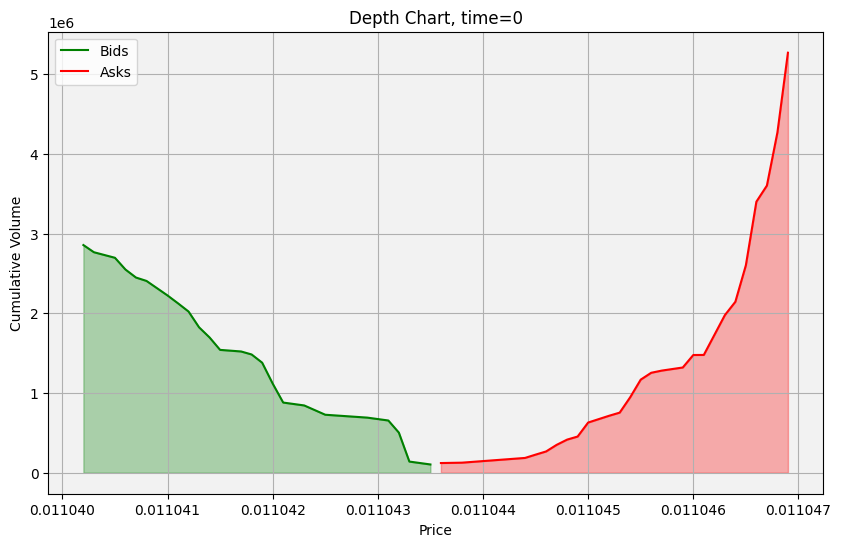

In [7]:
data = lob.T[0]

asks_prices, asks_volumes = data[2::4], data[3::4]
bids_prices, bids_volumes = data[4::4], data[5::4]

asks_cumulative_volume = [sum(asks_volumes[:i]) for i in range(1, len(asks_volumes) + 1)]
bids_cumulative_volume = [sum(bids_volumes[:i]) for i in range(1, len(bids_volumes) + 1)]

plt.figure(figsize=(10, 6))

plt.fill_between(bids_prices, bids_cumulative_volume, color='green', alpha=0.3)
plt.plot(bids_prices, bids_cumulative_volume, color='green', label='Bids')

plt.fill_between(asks_prices, asks_cumulative_volume, color='red', alpha=0.3)
plt.plot(asks_prices, asks_cumulative_volume, color='red', label='Asks')

plt.xlabel('Price')
plt.ylabel('Cumulative Volume')
plt.title('Depth Chart, time=0')
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.set_facecolor((0.95, 0.95, 0.95))
plt.show()

Посмотрим как менялась цена актива

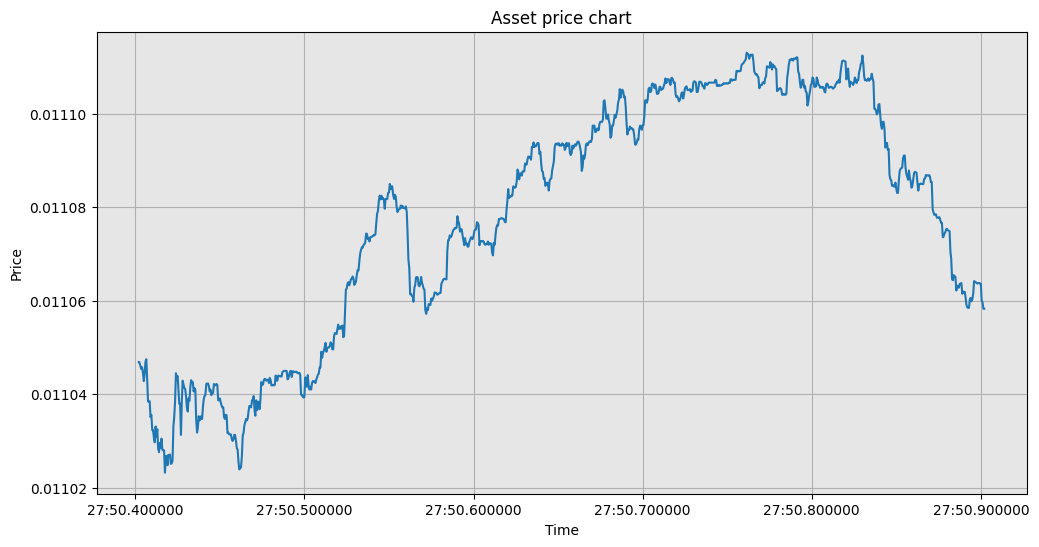

In [8]:
plt.figure(figsize=(12, 6))
time = pd.to_datetime(lob['local_timestamp'])
# plt.fill_between(time, lob["asks[24].price"], color='blue', alpha=0.1)
plt.plot(time, lob["asks[24].price"])
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Asset price chart")
plt.grid(True)
ax = plt.gca()
ax.set_facecolor((0.9, 0.9, 0.9))
plt.show()

#### Задание 1. Выбор таргета

За справедливую цену будем считать взешенную сумму закрытия сделки в один момент времени.

Таргет -- направление изменения цены в следующий момент времени, то есть рост/падение

Объединим датасеты

Сагрегируем данные торгов так, чтобы они собрались в одну группу: от одного состояния ордербука до другого.

In [9]:
trades['side'] = trades['side'].map({'buy': 1, 'sell': -1})

In [12]:
def agg_data2(lob, trades):
    lob_timestamps = lob['local_timestamp'].values
    trade_timestamps = trades['local_timestamp'].values
    trade_sides = trades['side'].values
    trade_amounts = trades['amount'].values
    trade_prices = trades['price'].values

    trades_agg_data = []

    for i in tqdm(range(len(lob_timestamps) - 1)):
        current_timestamp = lob_timestamps[i]
        next_timestamp = lob_timestamps[i + 1]

        in_interval = (trade_timestamps >= current_timestamp) & (trade_timestamps < next_timestamp)
        trades_in_interval = in_interval.nonzero()[0]  # индексы сделок в интервале

        if len(trades_in_interval) > 0:
            trades_side = trade_sides[trades_in_interval]
            trades_amount = trade_amounts[trades_in_interval]
            trades_price = trade_prices[trades_in_interval]

            buy_amount = trades_amount[trades_side == 1].sum()
            sell_amount = trades_amount[trades_side == -1].sum()
            total_amount = trades_amount.sum()

            if total_amount > 0:
                weighted_price = np.sum(trades_price * trades_amount) / total_amount
                side = np.sign(np.sum(trades_amount * trades_side))
            else:
                weighted_price = np.nan
                side = -1

            trades_agg_data.append([
                current_timestamp,
                buy_amount,
                sell_amount,
                weighted_price,
                side
            ])

    trades_agg = pd.DataFrame(trades_agg_data, columns=['local_timestamp', 'buy_amount', 'sell_amount', 'price', 'side'])

    trades_agg = trades_agg.sort_values(by='local_timestamp').reset_index(drop=True)
    trades_agg['side'] = trades_agg['side'].replace(0, -1)

    return trades_agg

In [14]:
trades_agg = agg_data2(lob, trades)

100%|██████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 59952.92it/s]


In [15]:
trades_agg.head()

,local_timestamp,buy_amount,sell_amount,price,side
0,1722470402305331,48228,1095493,0.011041,-1
1,1722470403485121,286594,0,0.011042,1
2,1722470403950214,0,2050,0.011042,-1
3,1722470404424495,15987,1158671,0.011041,-1
4,1722470405001648,74156,21265,0.011041,1


In [16]:
def ffill_emptys(trades_agg):
    trades_agg['sell_amount'] = trades_agg['sell_amount'].fillna(0)
    trades_agg['buy_amount'] = trades_agg['buy_amount'].fillna(0)
    trades_agg['price'] = trades_agg['price'].ffill().bfill()
    trades_agg['side'] = trades_agg['side'].ffill().bfill()
    trades_agg[trades_agg['side'] == 0]['side'] = -1

In [17]:
ffill_emptys(trades_agg)

Мерджим таблицы по пересечению, но поскольку они были собранны по lob[local_timestamp], то не имеет значения каким образом их мерджить.

In [18]:
mdf = pd.merge(lob, trades_agg, on='local_timestamp', how='inner')

In [19]:
mdf.head()

,Unnamed: 0,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,...,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,buy_amount,sell_amount,price,side
0,1,1722470402305331,0.011044,121492.0,0.011043,100499.0,0.011044,4663.0,0.011043,36226.0,...,0.011040,69663.0,0.011047,1000463.0,0.011040,90028.0,48228,1095493,0.011041,-1
1,2,1722470403485121,0.011041,60925.0,0.011041,747323.0,0.011041,59430.0,0.011040,337839.0,...,0.011038,77932.0,0.011045,162045.0,0.011038,2520.0,286594,0,0.011042,1
2,3,1722470403950214,0.011042,47154.0,0.011042,659456.0,0.011042,721458.0,0.011041,168126.0,...,0.011039,109781.0,0.011046,4619.0,0.011038,132214.0,0,2050,0.011042,-1
3,4,1722470404424495,0.011042,463599.0,0.011042,34546.0,0.011042,4619.0,0.011041,102775.0,...,0.011038,61706.0,0.011045,638314.0,0.011038,27842.0,15987,1158671,0.011041,-1
4,5,1722470405001648,0.011040,554238.0,0.011039,74024.0,0.011040,16620.0,0.011039,2029.0,...,0.011036,691780.0,0.011043,59430.0,0.011036,110382.0,74156,21265,0.011041,1


#### Задание 2. Метрика + класс задачи

Перед нами задача классификации (цена вырастет/упадет) мерить качество будем с помощью Log-loss, так как показатель уверености нам тоже не помешает.
    

#### Задание 3. Фичи


Посчитаем: spread, а также глубину рынка, имбаланс ордербука, скорость изменения цены и скорость изменения объема на уровне 0.  

In [21]:
#  spread
def spread(row):
    return row['asks[0].price'] - row['bids[0].price']

In [22]:
# глубина рынка на уровне 0
def depth_level_0(row):
    return row['asks[0].amount'] + row['bids[0].amount']

In [24]:
# имбаланс ордербука на уровне 0
def imbalance_level_0(row):
    return row['asks[0].amount'] / (row['asks[0].amount'] + row['bids[0].amount'] + 1)

In [25]:
# скорость изменения цены аска на уровне 0
def ask_price_change_rate(df, i):
    return (df['asks[0].price'].iloc[i] - df['asks[0].price'].iloc[i - 1]) / (df['local_timestamp'].iloc[i] - df['local_timestamp'].iloc[i - 1])

In [26]:
# скорость изменения объема аска на уровне 0
def ask_amount_change_rate(df, i):
    return (df['asks[0].amount'].iloc[i] - df['asks[0].amount'].iloc[i - 1]) / (df['local_timestamp'].iloc[i] - df['local_timestamp'].iloc[i - 1])

##### Ордербук фичи

In [27]:
def order_book_features(mdf):
    mdf['spread'] = mdf.apply(spread, axis=1)
    mdf['depth_level_0'] = mdf.apply(depth_level_0, axis=1)
    mdf['imbalance_level_0'] = mdf.apply(imbalance_level_0, axis=1)
    mdf['ask_price_change_rate'] = [0] + [ask_price_change_rate(mdf, i) for i in range(1, len(mdf))]
    mdf['ask_amount_change_rate'] = [0] + [ask_amount_change_rate(mdf, i) for i in range(1, len(mdf))]

In [28]:
order_book_features(mdf)

In [35]:
mdf

,Unnamed: 0,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,...,bids[24].amount,buy_amount,sell_amount,price,side,spread,depth_level_0,imbalance_level_0,ask_price_change_rate,ask_amount_change_rate
0,1,1722470402305331,0.011044,121492.0,0.011043,100499.0,0.011044,4663.0,0.011043,36226.0,...,90028.0,48228,1095493,0.011041,-1,1.000000e-07,221991.0,0.547281,0.000000e+00,0.000000
1,2,1722470403485121,0.011041,60925.0,0.011041,747323.0,0.011041,59430.0,0.011040,337839.0,...,2520.0,286594,0,0.011042,1,1.000000e-07,808248.0,0.075379,-2.373304e-12,-0.051337
2,3,1722470403950214,0.011042,47154.0,0.011042,659456.0,0.011042,721458.0,0.011041,168126.0,...,132214.0,0,2050,0.011042,-1,1.000000e-07,706610.0,0.066733,2.580129e-12,-0.029609
3,4,1722470404424495,0.011042,463599.0,0.011042,34546.0,0.011042,4619.0,0.011041,102775.0,...,27842.0,15987,1158671,0.011041,-1,1.000000e-07,498145.0,0.930649,0.000000e+00,0.878055
4,5,1722470405001648,0.011040,554238.0,0.011039,74024.0,0.011040,16620.0,0.011039,2029.0,...,110382.0,74156,21265,0.011041,1,1.000000e-07,628262.0,0.882175,-4.331607e-12,0.157045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,991,1722470897962083,0.011061,374239.0,0.011061,78131.0,0.011061,94223.0,0.011060,26039.0,...,98477.0,11820,0,0.011061,1,1.000000e-07,452370.0,0.827283,0.000000e+00,-0.047599
830,992,1722470898491811,0.011061,430235.0,0.011061,99402.0,0.011061,94223.0,0.011060,26039.0,...,98477.0,33014,0,0.011061,1,1.000000e-07,529637.0,0.812319,0.000000e+00,0.105707
831,993,1722470898968576,0.011061,171000.0,0.011061,161148.0,0.011061,94223.0,0.011060,36107.0,...,1492.0,20011,0,0.011061,1,1.000000e-07,332148.0,0.514829,0.000000e+00,-0.543737
832,995,1722470899965386,0.011061,137195.0,0.011061,236211.0,0.011061,94223.0,0.011060,36107.0,...,1492.0,14972,153720,0.011060,-1,1.000000e-07,373406.0,0.367414,0.000000e+00,-0.033913


#### Задание 4. ML-модель

Порубим на окна


In [37]:
def data_preprocess(mdf):
    split_index = int(0.7 * len(mdf))
    X_train = mdf[:split_index-1]
    y_train = mdf[1:split_index]['side']
    X_train.drop(['side'], axis=1, inplace=True)
    # print(X_train.head())
    y_train = label_encoder.fit_transform(y_train)

    X_test = mdf[split_index:-1]
    y_test = mdf[split_index + 1:]['side']
    X_test.drop(['side'], axis=1, inplace=True)
    y_test = label_encoder.fit_transform(y_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, y_train, X_test, y_test

Поучимся

In [38]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

models = [
    ('RandomForest', RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20],
    }),
    ('LogisticRegression', LogisticRegression(random_state=42, max_iter=5000, tol=1e-5), {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'saga', 'liblinear'],
    }),
    ('SVM', SVC(random_state=42), {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
    }),
    # ('CatBoost', CatBoostClassifier(random_seed=42, verbose=False), {
    #     'iterations': [100],
    #     'learning_rate': [0.1, 0.5],
    #     'depth': [10],
    # }),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss'), {
        'n_estimators': [100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
    }),
    ('LightGBM', LGBMClassifier(random_state=42, force_col_wise=True, verbose=-1), {
        'n_estimators': [50],
        'learning_rate': [0.01],
        'max_depth': [5, 7],
    }),
    ('GradientBoosting', GradientBoostingClassifier(random_state=42), {
        'n_estimators': [100],
        'learning_rate': [0.5, 1],
        'max_depth': [10],
    }),
    ('AdaBoost', AdaBoostClassifier(algorithm='SAMME', random_state=42), {
        'n_estimators': [110, 115, 120],
        'learning_rate': [10, 11, 12, 13],
    }),
]

label_encoder = LabelEncoder()


In [39]:
results = {}
accuracys = []
X_train, y_train, X_test, y_test = data_preprocess(mdf)

for model_name, model, param_grid in tqdm(models):
    logging.disable(logging.CRITICAL)
    warnings.filterwarnings('ignore')
    start_time = time.time()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)
    predictions = []
    results[model_name] = {}
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    # print(f"{best_model = }")
    y_pred = best_model.predict(X_test)

    elapsed_time = time.time() - start_time
    results[model_name]['accuracy'] = accuracy_score(y_test, y_pred)
    results[model_name]['log_loss'] = log_loss(y_test, y_pred)
    results[model_name]['best_params'] = grid_search.best_params_
    results[model_name]['elapsed_time'] = elapsed_time

  0%|                                                                         | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 6 candidates, totalling 30 fits


 14%|█████████▎                                                       | 1/7 [00:01<00:11,  1.87s/it]

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/Users/vl/DataspellProjects/ipynb/venv312/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/vl/DataspellProjects/ipynb/venv312/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/vl/DataspellProjects/ipynb/venv312/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/vl/DataspellProjects/ipynb/venv312/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/vl/DataspellProjects/ipynb/venv312/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did 

...

 71%|██████████████████████████████████████████████▍                  | 5/7 [00:05<00:01,  1.05it/s]

Fitting 5 folds for each of 2 candidates, totalling 10 fits


 86%|███████████████████████████████████████████████████████▋         | 6/7 [00:08<00:01,  1.64s/it]

Fitting 5 folds for each of 12 candidates, totalling 60 fits


100%|█████████████████████████████████████████████████████████████████| 7/7 [00:11<00:00,  1.62s/it]


In [40]:
pd.DataFrame(results).T.sort_values(by='log_loss', ascending=True)

,accuracy,log_loss,best_params,elapsed_time
AdaBoost,0.54,16.580081,"{'learning_rate': 11, 'n_estimators': 115}",2.927959
RandomForest,0.528,17.012604,"{'max_depth': 10, 'n_estimators': 100}",1.87042
GradientBoosting,0.512,17.589303,"{'learning_rate': 0.5, 'max_depth': 10, 'n_est...",2.974473
SVM,0.504,17.877652,"{'C': 0.1, 'kernel': 'rbf'}",0.751259
XGBoost,0.5,18.021827,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.726219
LightGBM,0.492,18.310176,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.910777
LogisticRegression,0.48,18.7427,"{'C': 10, 'solver': 'lbfgs'}",1.175279


#### Выводы:

Выбираем AdaBoost

In [41]:
lob1 = lob_data.copy()
trades1 = trades_data.copy()

In [42]:
trades1['side'] = trades1['side'].map({'buy': 1, 'sell': -1})

In [46]:
trades_agg1 = agg_data2(lob1, trades1)

100%|███████████████████████████████████████████████████| 1036689/1036689 [2:55:06<00:00, 98.67it/s]


In [49]:
trades_agg1

,local_timestamp,buy_amount,sell_amount,price,side
0,1722470402305331,48228,1095493,0.011041,-1
1,1722470403485121,286594,0,0.011042,1
2,1722470403950214,0,2050,0.011042,-1
3,1722470404424495,15987,1158671,0.011041,-1
4,1722470405001648,74156,21265,0.011041,1
...,...,...,...,...,...
890791,1722988797492233,74186,370082,0.007736,-1
890792,1722988797959508,393175,1216775,0.007736,-1
890793,1722988798480811,0,4732,0.007736,-1
890794,1722988799001710,5394,10000,0.007736,-1


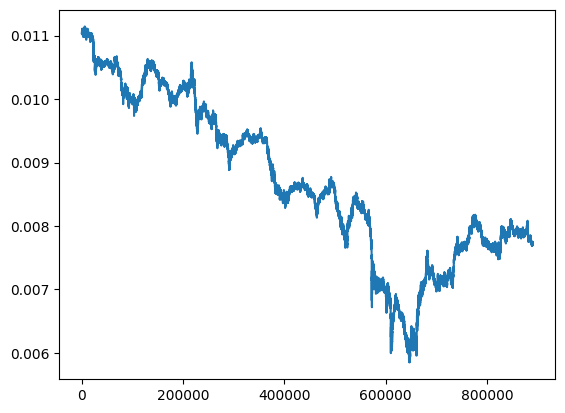

In [50]:
plt.plot(trades_agg1.index, trades_agg1.price);

In [51]:
ffill_emptys(trades_agg1)

In [52]:
mdf1 = pd.merge(lob1, trades_agg1, on='local_timestamp', how='inner')
order_book_features(mdf1)
X_train, y_train, X_test, y_test = data_preprocess(mdf1)

In [54]:
mdf1

,Unnamed: 0,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,...,bids[24].amount,buy_amount,sell_amount,price,side,spread,depth_level_0,imbalance_level_0,ask_price_change_rate,ask_amount_change_rate
0,1,1722470402305331,0.011044,121492.0,0.011043,100499.0,0.011044,4663.0,0.011043,36226.0,...,90028.0,48228,1095493,0.011041,-1,1.000000e-07,221991.0,0.547281,0.000000e+00,0.000000
1,2,1722470403485121,0.011041,60925.0,0.011041,747323.0,0.011041,59430.0,0.011040,337839.0,...,2520.0,286594,0,0.011042,1,1.000000e-07,808248.0,0.075379,-2.373304e-12,-0.051337
2,3,1722470403950214,0.011042,47154.0,0.011042,659456.0,0.011042,721458.0,0.011041,168126.0,...,132214.0,0,2050,0.011042,-1,1.000000e-07,706610.0,0.066733,2.580129e-12,-0.029609
3,4,1722470404424495,0.011042,463599.0,0.011042,34546.0,0.011042,4619.0,0.011041,102775.0,...,27842.0,15987,1158671,0.011041,-1,1.000000e-07,498145.0,0.930649,0.000000e+00,0.878055
4,5,1722470405001648,0.011040,554238.0,0.011039,74024.0,0.011040,16620.0,0.011039,2029.0,...,110382.0,74156,21265,0.011041,1,1.000000e-07,628262.0,0.882175,-4.331607e-12,0.157045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
890791,1036684,1722988797492233,0.007739,36662.0,0.007739,82700.0,0.007739,35007.0,0.007738,18684.0,...,69023.0,74186,370082,0.007736,-1,1.000000e-07,119362.0,0.307147,-1.517649e-12,-0.176015
890792,1036685,1722988797959508,0.007736,34317.0,0.007736,85933.0,0.007736,90719.0,0.007736,292931.0,...,11513.0,393175,1216775,0.007736,-1,1.000000e-07,120250.0,0.285378,-5.350169e-12,-0.005018
890793,1036686,1722988798480811,0.007736,172660.0,0.007736,136676.0,0.007736,74080.0,0.007736,149692.0,...,64599.0,0,4732,0.007736,-1,1.000000e-07,309336.0,0.558161,-3.836540e-13,0.265379
890794,1036687,1722988799001710,0.007736,94074.0,0.007736,152281.0,0.007736,225439.0,0.007735,2780.0,...,22484.0,5394,10000,0.007736,-1,1.000000e-07,246355.0,0.381862,-5.759274e-13,-0.150866


In [55]:
results = {}
accuracys = []

logging.disable(logging.CRITICAL)
warnings.filterwarnings('ignore')

start_time = time.time()
model_name = 'AdaBoost'
results[model_name] = {}
model = AdaBoostClassifier(algorithm='SAMME', random_state=42, n_estimators=115, learning_rate=11)
# model = SVC(random_state=42, kernel='rbf', C=1, verbose = 10, cache_size=2000 )
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

elapsed_time = time.time() - start_time
results[model_name]['accuracy'] = accuracy_score(y_test, y_pred)
results[model_name]['log_loss'] = log_loss(y_test, y_pred)
results[model_name]['elapsed_time'] = elapsed_time

In [57]:
print("Распределение классов в обучающей выборке:")
print(pd.Series(y_train).value_counts())

print("Распределение классов в тестовой выборке:")
print(pd.Series(y_test).value_counts())


Распределение классов в обучающей выборке:
1    318880
0    304676
Name: count, dtype: int64
Распределение классов в тестовой выборке:
1    135851
0    131387
Name: count, dtype: int64


In [60]:
pd.DataFrame(results).T.sort_values(by='log_loss', ascending=True)

,accuracy,log_loss,elapsed_time
AdaBoost,0.50833,17.721596,717.571694
